#機械学習の勉強　--練習問題

In [23]:
'''
#9-1
購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。

#9-2
・購入するか否かに大きな影響を与える要素を特定できる
・顧客の情報から購入するか否かを予測できる。
ゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。
'''

'\n#9-1\n購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。\n\n#9-2\n・購入するか否かに大きな影響を与える要素を特定できる\n・顧客の情報から購入するか否かを予測できる。\nゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。\n'

In [24]:
#9-3
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split

df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Bank.csv')
display(df.head(5))

display(df.isnull().sum())


,id,age,job,marital,education,default,amount,housing,loan,contact,day,month,duration,campaign,previous,y
0,1,39,blue-collar,married,secondary,no,1756.0,yes,no,cellular,3,apr,370.055237,1,0,1
1,2,51,entrepreneur,married,primary,no,1443.0,no,no,cellular,18,feb,233.998933,10,0,1
2,3,36,management,single,tertiary,no,436.0,no,no,cellular,13,apr,NaN,1,2,0
3,4,63,retired,married,secondary,no,474.0,no,no,cellular,25,jan,252.525808,1,0,0
4,5,31,management,single,tertiary,no,354.0,no,no,cellular,30,apr,NaN,1,2,0


id              0
age             0
job             0
marital         0
education       0
default         0
amount          0
housing         0
loan            0
contact         0
day             0
month           0
duration     7044
campaign        0
previous        0
y               0
dtype: int64

In [25]:
#名義尺度のダミー変数化
to_dummies=['job','marital','default','housing','loan','contact']
for col in to_dummies:
    dummied=pd.get_dummies(df[col],drop_first=True,dtype=int)
    df=pd.concat([df,dummied],axis=1)
    df=df.drop(col,axis=1)

display(df.head(5))


,id,age,education,amount,day,month,duration,campaign,previous,y,...,technician,unemployed,unknown,married,single,yes,yes,yes,sending _document,telephone
0,1,39,secondary,1756.0,3,apr,370.055237,1,0,1,...,0,0,0,1,0,0,1,0,0,0
1,2,51,primary,1443.0,18,feb,233.998933,10,0,1,...,0,0,0,1,0,0,0,0,0,0
2,3,36,tertiary,436.0,13,apr,NaN,1,2,0,...,0,0,0,0,1,0,0,0,0,0
3,4,63,secondary,474.0,25,jan,252.525808,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,31,tertiary,354.0,30,apr,NaN,1,2,0,...,0,0,0,0,1,0,0,0,0,0


In [26]:

#順序尺度のダミー変数化
#education,monthは順序尺度

display(df['education'].unique())
display(df['month'].unique())

education_map={
    'unknown':0,
    'primary':1,
    'secondary':2,
    'tertiary':3
}
df['education']=df['education'].map(education_map)

month_map={
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12
}
df['month']=df['month'].map(month_map)

df=df.drop(['education'],axis=1)
df=df.drop(['month'],axis=1)

array(['secondary', 'primary', 'tertiary', 'unknown'], dtype=object)

array(['apr', 'feb', 'jan', 'jun', 'sep', 'may', 'aug', 'mar', 'jul',
       'nov', 'oct', 'dec'], dtype=object)

In [27]:
#テストデータの分離
train_val,test=train_test_split(df,test_size=0.2,random_state=0)

In [28]:
print(df.columns)
display(df.head(10))

Index(['id', 'age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'yes', 'yes', 'yes',
       'sending _document', 'telephone'],
      dtype='object')


,id,age,amount,day,duration,campaign,previous,y,blue-collar,entrepreneur,...,technician,unemployed,unknown,married,single,yes,yes,yes,sending _document,telephone
0,1,39,1756.0,3,370.055237,1,0,1,1,0,...,0,0,0,1,0,0,1,0,0,0
1,2,51,1443.0,18,233.998933,10,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
2,3,36,436.0,13,NaN,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,4,63,474.0,25,252.525808,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,5,31,354.0,30,NaN,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,0
5,6,29,260.0,2,238.385368,14,0,0,1,0,...,0,0,0,0,1,0,1,0,1,0
6,7,37,52.0,6,350.269989,1,9,1,0,0,...,0,0,0,1,0,0,1,0,0,0
7,8,32,449.0,18,359.912130,1,8,0,0,0,...,1,0,0,0,1,0,1,0,0,0
8,9,31,0.0,7,292.503403,2,2,0,0,0,...,0,0,0,0,1,0,1,0,0,0
9,10,32,1815.0,10,184.903837,1,2,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [34]:
#列名のうち重複しているものを変更
df.columns=['id', 'age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'unknown', 'married', 'single', 'default', 'housing', 'loan',
       'sending _document', 'telephone']

In [31]:
df.shape

(27128, 26)

<Axes: >

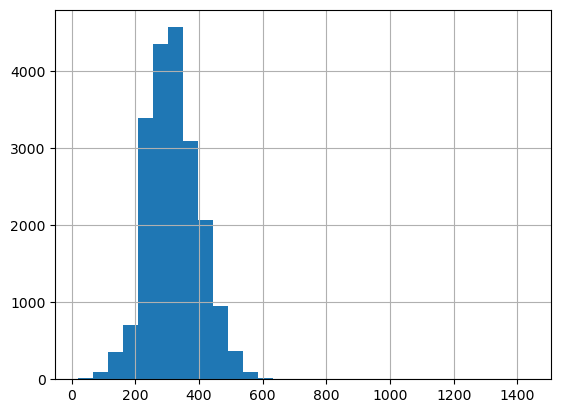

In [ ]:
#durationが欠損している人にどのような特徴があるか調べる
df["duration_missing"] = df["duration"].isna()

df["duration"].hist(bins=30)    #ヒストグラムを書く


In [43]:
#durationが欠損している人にどのような特徴があるか調べる
display(df.groupby("duration_missing").mean(numeric_only=True).T)    #平均

duration_missing,False,True
id,13572.603764,13541.394378
age,41.635730,38.998722
amount,1304.166750,1463.969620
day,15.781169,15.877626
duration,318.222068,NaN
campaign,2.780123,2.670926
previous,0.612976,0.484952
y,0.356055,0.217490
blue-collar,0.236606,0.160988
entrepreneur,0.035750,0.027825


In [ ]:
#各グループでの欠損値の個数を調べる
cols=df.columns
for col in cols:
    pd.crosstab(col, df["duration_missing"])

In [ ]:
#各グループごとのdurationの平均を調べる
cols=df.columns
for col in cols:
    display(df.groupby(col)["duration"].mean())

In [30]:
#欠損値の補完
#まずグループ化してdurationの傾向を調査
cols=df.columns

for col in cols:
    display(df.groupby('duration')[col].mean())

duration
19.038719       2744.0
34.009388      24935.0
46.910033       4856.0
50.514705      18832.0
50.983477      20412.0
                ...   
610.989820      3428.0
612.402981      6083.0
615.048733     17427.0
632.388923     26708.0
1435.488040     3141.0
Name: id, Length: 20084, dtype: float64

duration
19.038719      21.0
34.009388      23.0
46.910033      31.0
50.514705      36.0
50.983477      22.0
               ... 
610.989820     56.0
612.402981     52.0
615.048733     55.0
632.388923     60.0
1435.488040    40.0
Name: age, Length: 20084, dtype: float64

duration
19.038719       200.0
34.009388      1003.0
46.910033      1601.0
50.514705        98.0
50.983477      1258.0
                ...  
610.989820     1554.0
612.402981       57.0
615.048733      956.0
632.388923      174.0
1435.488040     543.0
Name: amount, Length: 20084, dtype: float64

duration
19.038719       1.0
34.009388      27.0
46.910033       7.0
50.514705       4.0
50.983477      10.0
               ... 
610.989820      6.0
612.402981     20.0
615.048733      5.0
632.388923      2.0
1435.488040     2.0
Name: day, Length: 20084, dtype: float64

duration
19.038719        19.038719
34.009388        34.009388
46.910033        46.910033
50.514705        50.514705
50.983477        50.983477
                  ...     
610.989820      610.989820
612.402981      612.402981
615.048733      615.048733
632.388923      632.388923
1435.488040    1435.488040
Name: duration, Length: 20084, dtype: float64

...

,yes,yes,yes
duration,,,
19.038719,0.0,0.0,0.0
34.009388,0.0,0.0,0.0
46.910033,0.0,0.0,0.0
50.514705,0.0,0.0,0.0
50.983477,0.0,0.0,0.0
...,...,...,...
610.989820,0.0,1.0,1.0
612.402981,1.0,1.0,1.0
615.048733,0.0,1.0,1.0


,yes,yes,yes
duration,,,
19.038719,0.0,0.0,0.0
34.009388,0.0,0.0,0.0
46.910033,0.0,0.0,0.0
50.514705,0.0,0.0,0.0
50.983477,0.0,0.0,0.0
...,...,...,...
610.989820,0.0,1.0,1.0
612.402981,1.0,1.0,1.0
615.048733,0.0,1.0,1.0


,yes,yes,yes
duration,,,
19.038719,0.0,0.0,0.0
34.009388,0.0,0.0,0.0
46.910033,0.0,0.0,0.0
50.514705,0.0,0.0,0.0
50.983477,0.0,0.0,0.0
...,...,...,...
610.989820,0.0,1.0,1.0
612.402981,1.0,1.0,1.0
615.048733,0.0,1.0,1.0


duration
19.038719      1.0
34.009388      0.0
46.910033      0.0
50.514705      0.0
50.983477      0.0
              ... 
610.989820     0.0
612.402981     0.0
615.048733     0.0
632.388923     0.0
1435.488040    0.0
Name: sending _document, Length: 20084, dtype: float64

duration
19.038719      0.0
34.009388      1.0
46.910033      0.0
50.514705      0.0
50.983477      0.0
              ... 
610.989820     0.0
612.402981     0.0
615.048733     0.0
632.388923     0.0
1435.488040    0.0
Name: telephone, Length: 20084, dtype: float64

In [ ]:
#不均衡データを考慮したうえでのモデル作成・学習
model=tree.DecisionTreeClassifier(max_depth=5,random_state=0,class_weight='balanced')